## Test the Usage

### See the Registry

In [1]:
import pprint
from findcrack.models.registry import MODEL_REGISTRY

# pprint.pprint(MODEL_REGISTRY)

d:\codes\projects\interns\intern-year-four\crack\findcrack\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import cv2
from findcrack import CrackInferencePipeline, load_model

print("Import successful")

Import successful


In [3]:
# 1. Load the registered model from the registry
model = load_model("Seg_YOLO26n-seg-v1_crack-seg", device="cpu")

In [4]:
# 2. Setup the inference pipeline
pipeline = CrackInferencePipeline(
    model=model,
    device="cuda",
    patch_size=1024,
    use_tta=False
)

In [5]:
# 3. Perform inference
results = pipeline.predict(r"D:\codes\projects\interns\intern-year-four\crack\findcrack\assets\images\CFD_001.jpg")

In [6]:
# Save the output mask, overlay, and visual bounding boxes
cv2.imwrite("./images/predicted/detected_cracks.png", results["binary_mask"])
cv2.imwrite("./images/predicted/detected_cracks_overlay.png", results["overlay"])
cv2.imwrite("./images/predicted/detected_cracks_visualization.png", results["visualization"])

False

C:\Users\ngt32\AppData\Local\Temp\ipykernel_17932\2451418226.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


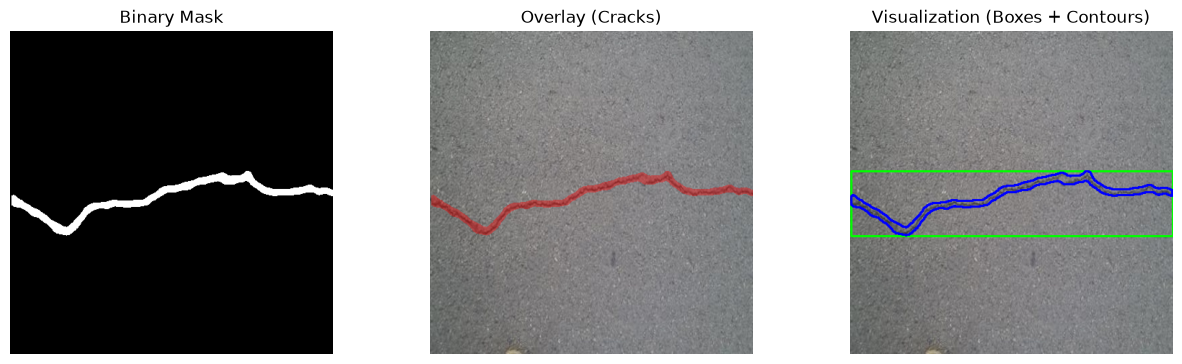

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure with 3 subplots
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, wspace=0.3, hspace=0.3)

# 1. Binary Mask
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(results["binary_mask"], cmap='gray')
ax1.set_title('Binary Mask')
ax1.axis('off')

# 2. Overlay
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(results["overlay"])
ax2.set_title('Overlay (Cracks)')
ax2.axis('off')

# 3. Visualization with Bounding Boxes and Contours
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(results["visualization"])
ax3.set_title('Visualization (Boxes + Contours)')
ax3.axis('off')

# Use tight_layout only once at the end
plt.tight_layout()

# Optional: Save the plot as well
plt.savefig('predicted_images_plot.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()

# Close the figure to free memory
plt.close()